# 🏆 AltScore — Final Model: All Novelties Combined
### Zenith Hackathon 5.0 | Team: TECH CRUSADERS

Complete end-to-end pipeline integrating **all three novelty features**:
- 🔵 **Phase 1** — Financial Trajectory Feature Engineering
- 🟢 **Phase 2** — Model Training & Evaluation (4 models)
- 🟡 **Phase 3** — Counterfactual Explanations (XAI)
- 🟠 **Phase 4** — Fairness Analysis (Bias Audit)
- ⭐ **Phase 5** — Final Summary


---
## 📦 Imports & Configuration

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib
from scipy.optimize import minimize, differential_evolution

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.preprocessing import StandardScaler

from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ── Paths ──────────────────────────────────────────────────────────────────
BASE_DIR = r"d:\\ALTSCORE-Credit Scoring System"
X_PATH   = os.path.join(BASE_DIR, r"D:\ZENITH\ALTSCORE-Credit Scoring System\X_final.csv")
Y_PATH   = os.path.join(BASE_DIR, r"D:\ZENITH\ALTSCORE-Credit Scoring System\y_final.csv")
INST_PATH= os.path.join(BASE_DIR, "dataset", r"D:\ZENITH\ALTSCORE-Credit Scoring System\installments_payments.csv")
MODELS_DIR  = os.path.join(BASE_DIR, "models")
REPORTS_DIR = os.path.join(BASE_DIR, "reports")
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

RANDOM_STATE = 42
print("✅ Imports complete — paths configured")
print(f"   Base : {BASE_DIR}")


✅ Imports complete — paths configured
   Base : d:\\ALTSCORE-Credit Scoring System


---
## 🔵 Phase 1 — Financial Trajectory Feature Engineering
Novelty by **Muskan** — tracks whether a customer's payment behaviour is
improving or declining over time using installment history.

**Features created:**
| Feature | Description |
|---------|-------------|
| `TRAJECTORY_EARLY_LATE_RATE` | Late-payment rate in the first half of history |
| `TRAJECTORY_RECENT_LATE_RATE` | Late-payment rate in the second/recent half |
| `TRAJECTORY_SLOPE` | Linear-regression slope on on-time behaviour |
| `TRAJECTORY_IMPROVEMENT` | 1 if recent rate < early rate, else 0 |
| `TRAJECTORY_SCORE` | Clipped score derived from slope |


In [32]:
def calculate_trajectory_features(installments_path):
    """
    Compute per-customer payment trajectory features from installment history.
    Returns a DataFrame indexed by SK_ID_CURR with 5 trajectory columns.
    """
    print("⏳ Loading installments_payments.csv …")
    cols = ['SK_ID_CURR', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT']
    df = pd.read_csv(installments_path, usecols=cols)

    # 1 = on-time/early, 0 = late
    df['ON_TIME'] = (df['DAYS_ENTRY_PAYMENT'] <= df['DAYS_INSTALMENT']).astype(int)
    df = df.sort_values(['SK_ID_CURR', 'DAYS_INSTALMENT'])

    # ── Early vs Recent late rates ──────────────────────────────────────────
    def early_recent_rates(grp):
        n = len(grp)
        mid = max(1, n // 2)
        early  = 1 - grp['ON_TIME'].iloc[:mid].mean()
        recent = 1 - grp['ON_TIME'].iloc[mid:].mean()
        return pd.Series({'TRAJECTORY_EARLY_LATE_RATE': early,
                          'TRAJECTORY_RECENT_LATE_RATE': recent})

    res = df.groupby('SK_ID_CURR').apply(early_recent_rates)
    res = res.reset_index()

    # ── Slope of on-time behaviour ──────────────────────────────────────────
    df['n']      = df.groupby('SK_ID_CURR')['SK_ID_CURR'].transform('count')
    df['x']      = df.groupby('SK_ID_CURR').cumcount()
    df['x_mean'] = (df['n'] - 1) / 2.0
    df['y_mean'] = df.groupby('SK_ID_CURR')['ON_TIME'].transform('mean')
    df['dx']     = df['x'] - df['x_mean']
    df['dy']     = df['ON_TIME'] - df['y_mean']

    slope_num = df.groupby('SK_ID_CURR')['dx'].apply(lambda s: (s * df.loc[s.index, 'dy']).sum())
    slope_den = df.groupby('SK_ID_CURR')['dx'].apply(lambda s: (s ** 2).sum())
    slope = (slope_num / slope_den.replace(0, np.nan)).fillna(0)
    slope.name = 'TRAJECTORY_SLOPE'

    traj = res.set_index('SK_ID_CURR').join(slope)
    traj['TRAJECTORY_IMPROVEMENT'] = (
        traj['TRAJECTORY_RECENT_LATE_RATE'] < traj['TRAJECTORY_EARLY_LATE_RATE']
    ).astype(int)
    traj['TRAJECTORY_SCORE'] = np.clip(0.5 + traj['TRAJECTORY_SLOPE'] * 10, 0, 1)

    print(f"✅ Trajectory features calculated for {len(traj):,} customers.")
    return traj.reset_index()

traj_df = calculate_trajectory_features(INST_PATH)
print(traj_df.head())


⏳ Loading installments_payments.csv …
✅ Trajectory features calculated for 339,587 customers.
   SK_ID_CURR  TRAJECTORY_EARLY_LATE_RATE  TRAJECTORY_RECENT_LATE_RATE  \
0      100001                    0.333333                          0.0   
1      100002                    0.000000                          0.0   
2      100003                    0.000000                          0.0   
3      100004                    0.000000                          0.0   
4      100005                    0.000000                          0.2   

   TRAJECTORY_SLOPE  TRAJECTORY_IMPROVEMENT  TRAJECTORY_SCORE  
0          0.071429                       1               1.0  
1          0.000000                       0               0.5  
2          0.000000                       0               0.5  
3          0.000000                       0               0.5  
4          0.000000                       0               0.5  


---
## 🔀 Merge All Datasets
Start with X_final.csv (239 features) and left-join trajectory features on SK_ID_CURR.
Missing trajectory values are filled with the column mean.


In [33]:
import pandas as pd

print("⏳ Loading base datasets …")

X_base = pd.read_csv(X_PATH)
y      = pd.read_csv(Y_PATH).squeeze()

print(f"   X_base shape : {X_base.shape}")
print(f"   y shape      : {y.shape}")

X_base.columns = X_base.columns.str.strip().str.upper()
traj_df.columns = traj_df.columns.str.strip().str.upper()

X_merged = X_base.merge(traj_df, on='SK_ID_CURR', how='left')

NOVELTY_FEATURES = [
    col for col in X_merged.columns 
    if col.startswith("TRAJECTORY_")
]

print("\n🔍 Trajectory features detected:")
print(NOVELTY_FEATURES)

for col in NOVELTY_FEATURES:
    X_merged[col] = X_merged[col].fillna(X_merged[col].mean())

print(f"\n✅ Merged dataset shape : {X_merged.shape}")
print(f"   Original features   : {X_base.shape[1] - 1}")
print(f"   Trajectory added    : {len(NOVELTY_FEATURES)}")
print(f"   Total features      : {X_merged.shape[1] - 1} (excl. SK_ID_CURR)")

⏳ Loading base datasets …
   X_base shape : (307511, 240)
   y shape      : (307511,)

🔍 Trajectory features detected:
['TRAJECTORY_EARLY_LATE_RATE', 'TRAJECTORY_RECENT_LATE_RATE', 'TRAJECTORY_SLOPE', 'TRAJECTORY_IMPROVEMENT', 'TRAJECTORY_SCORE']

✅ Merged dataset shape : (307511, 245)
   Original features   : 239
   Trajectory added    : 5
   Total features      : 244 (excl. SK_ID_CURR)


---
## ⚙️ Preprocessing
- Drop SK_ID_CURR
- Fill remaining NaNs with column mean (fit on train only)
- Stratified 80-20 train-test split (random_state=42)


In [34]:
# Drop SK_ID_CURR
X_final = X_merged.drop(columns=['SK_ID_CURR'])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)
print(f"Train : {X_train.shape[0]:,}  |  Test : {X_test.shape[0]:,}")
print(f"Default rate — Train: {y_train.mean()*100:.2f}%  |  Test: {y_test.mean()*100:.2f}%")

# Impute with train-set mean (no leakage)
train_means = X_train.mean()
X_train = X_train.fillna(train_means)
X_test  = X_test.fillna(train_means)

print("✅ Preprocessing complete — no leakage")


Train : 246,008  |  Test : 61,503
Default rate — Train: 8.07%  |  Test: 8.07%
✅ Preprocessing complete — no leakage


---
## 🟢 Phase 2 — Model Training
Training 4 models on the **244-feature** merged dataset.


In [35]:
results  = {}   # model_name -> {'auc': float, 'model': fitted_model}
probs    = {}   # model_name -> y_pred_proba

# ── 4a. Logistic Regression ──────────────────────────────────────────────────
print("🔄 Training Logistic Regression …")
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)
lr.fit(X_train, y_train)
lr_prob = lr.predict_proba(X_test)[:, 1]
lr_auc  = roc_auc_score(y_test, lr_prob)
results['Logistic Regression'] = {'auc': lr_auc, 'model': lr}
probs  ['Logistic Regression'] = lr_prob
joblib.dump(lr, os.path.join(MODELS_DIR, 'logistic_regression.pkl'))
print(f"   Logistic Regression  ROC-AUC: {lr_auc:.4f}")

# ── 4b. Random Forest ────────────────────────────────────────────────────────
print("\n🔄 Training Random Forest …")
rf = RandomForestClassifier(
    n_estimators=100, max_depth=12,
    class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE
)
rf.fit(X_train, y_train)
rf_prob = rf.predict_proba(X_test)[:, 1]
rf_auc  = roc_auc_score(y_test, rf_prob)
results['Random Forest'] = {'auc': rf_auc, 'model': rf}
probs  ['Random Forest'] = rf_prob
joblib.dump(rf, os.path.join(MODELS_DIR, 'random_forest.pkl'))
print(f"   Random Forest        ROC-AUC: {rf_auc:.4f}")

# ── 4c. LightGBM ────────────────────────────────────────────────────────────
print("\n🔄 Training LightGBM …")
lgb = LGBMClassifier(
    n_estimators=1000, learning_rate=0.02, max_depth=7,
    scale_pos_weight=11, n_jobs=-1, random_state=RANDOM_STATE,
    verbose=-1
)
lgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[])
lgb_prob = lgb.predict_proba(X_test)[:, 1]
lgb_auc  = roc_auc_score(y_test, lgb_prob)
results['LightGBM'] = {'auc': lgb_auc, 'model': lgb}
probs  ['LightGBM'] = lgb_prob
joblib.dump(lgb, os.path.join(MODELS_DIR, 'lightgbm.pkl'))
print(f"   LightGBM             ROC-AUC: {lgb_auc:.4f}")

# ── 4d. XGBoost ─────────────────────────────────────────────────────────────
print("\n🔄 Training XGBoost …")
xgb = XGBClassifier(
    n_estimators=1000, learning_rate=0.03, max_depth=6,
    scale_pos_weight=11, n_jobs=-1, random_state=RANDOM_STATE,
    eval_metric='auc', verbosity=0, use_label_encoder=False
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_auc  = roc_auc_score(y_test, xgb_prob)
results['XGBoost'] = {'auc': xgb_auc, 'model': xgb}
probs  ['XGBoost'] = xgb_prob
joblib.dump(xgb, os.path.join(MODELS_DIR, 'xgboost.pkl'))
print(f"   XGBoost              ROC-AUC: {xgb_auc:.4f}")

print("\n✅ All 4 models trained and saved.")


🔄 Training Logistic Regression …
   Logistic Regression  ROC-AUC: 0.7407

🔄 Training Random Forest …
   Random Forest        ROC-AUC: 0.7563

🔄 Training LightGBM …
   LightGBM             ROC-AUC: 0.7881

🔄 Training XGBoost …
   XGBoost              ROC-AUC: 0.7829

✅ All 4 models trained and saved.


---
## 📊 Model Evaluation


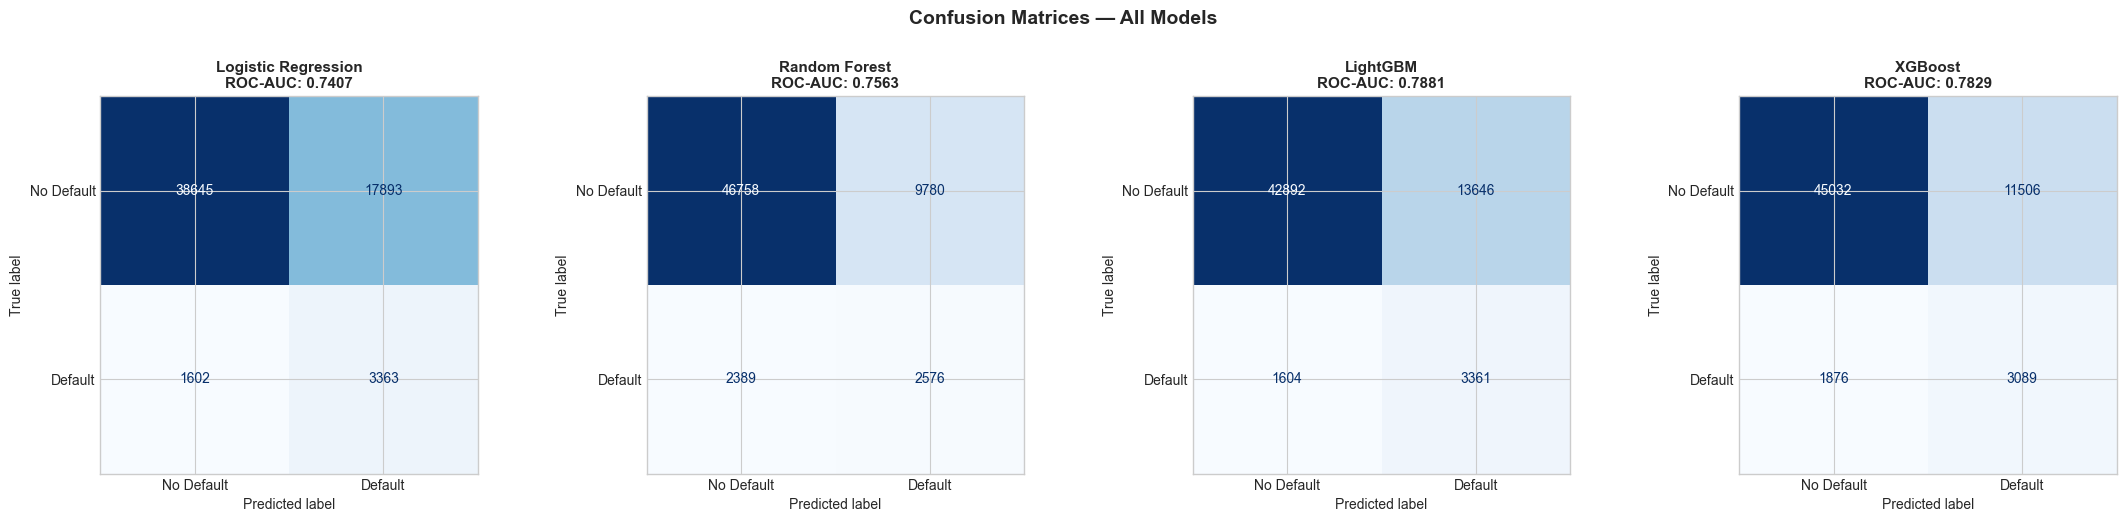

✅ Confusion matrices saved

  Logistic Regression  |  ROC-AUC: 0.7407
              precision    recall  f1-score   support

  No Default     0.9602    0.6835    0.7986     56538
     Default     0.1582    0.6773    0.2565      4965

    accuracy                         0.6830     61503
   macro avg     0.5592    0.6804    0.5275     61503
weighted avg     0.8955    0.6830    0.7548     61503


  Random Forest  |  ROC-AUC: 0.7563
              precision    recall  f1-score   support

  No Default     0.9514    0.8270    0.8849     56538
     Default     0.2085    0.5188    0.2974      4965

    accuracy                         0.8021     61503
   macro avg     0.5799    0.6729    0.5911     61503
weighted avg     0.8914    0.8021    0.8374     61503


  LightGBM  |  ROC-AUC: 0.7881
              precision    recall  f1-score   support

  No Default     0.9640    0.7586    0.8491     56538
     Default     0.1976    0.6769    0.3059      4965

    accuracy                         0.7520

In [36]:
COLORS = {
    'Logistic Regression': '#3498db',
    'Random Forest':       '#2ecc71',
    'LightGBM':            '#e67e22',
    'XGBoost':             '#e74c3c',
}

# ── 5a. Confusion matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, res) in zip(axes, results.items()):
    model = res['model']
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nROC-AUC: {res['auc']:.4f}", fontsize=11, fontweight='bold')
plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'confusion_matrices.png'), dpi=120, bbox_inches='tight')
plt.show()
print("✅ Confusion matrices saved")

# ── 5b. Classification Reports ───────────────────────────────────────────
for name, res in results.items():
    model = res['model']
    y_pred = model.predict(X_test)
    print(f"\n{'='*60}")
    print(f"  {name}  |  ROC-AUC: {res['auc']:.4f}")
    print('='*60)
    print(classification_report(y_test, y_pred,
                                target_names=['No Default', 'Default'],
                                digits=4))


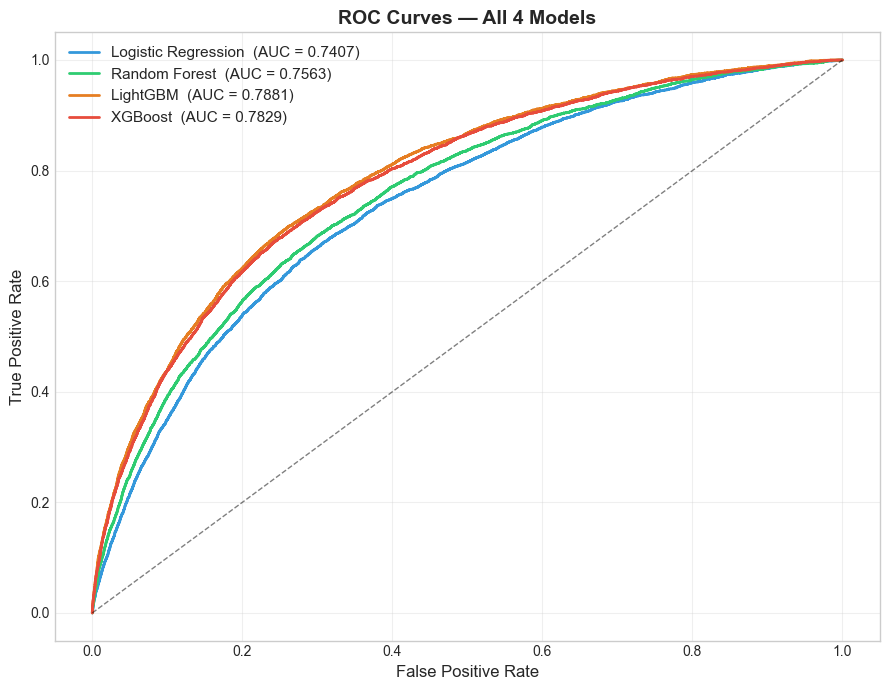

✅ ROC curves saved


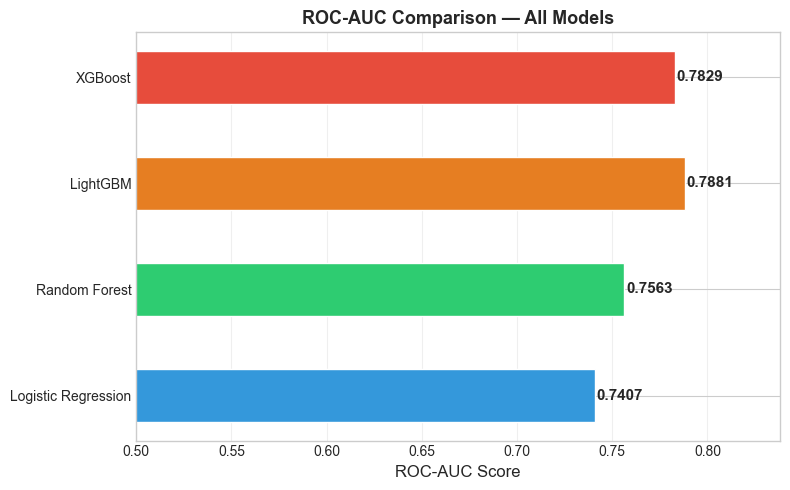

✅ AUC bar chart saved


In [37]:
# ── 5c. ROC Curves (all 4 on one chart) ──────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
for name, prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    ax.plot(fpr, tpr, lw=2, color=COLORS[name],
            label=f"{name}  (AUC = {results[name]['auc']:.4f})")
ax.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All 4 Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'roc_curves_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()
print("✅ ROC curves saved")

# ── 5d. Bar chart comparing AUCs ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
names = list(results.keys())
aucs  = [results[n]['auc'] for n in names]
colors= [COLORS[n] for n in names]
bars  = ax.barh(names, aucs, color=colors, edgecolor='white', height=0.5)
for bar, auc in zip(bars, aucs):
    ax.text(auc + 0.001, bar.get_y() + bar.get_height()/2,
            f'{auc:.4f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlim(0.5, max(aucs) + 0.05)
ax.set_xlabel('ROC-AUC Score', fontsize=12)
ax.set_title('ROC-AUC Comparison — All Models', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, 'auc_bar_chart.png'), dpi=120, bbox_inches='tight')
plt.show()
print("✅ AUC bar chart saved")


---
## ⭐ Best Model & Feature Importance


🏆 Best Model: LightGBM  |  ROC-AUC: 0.7881


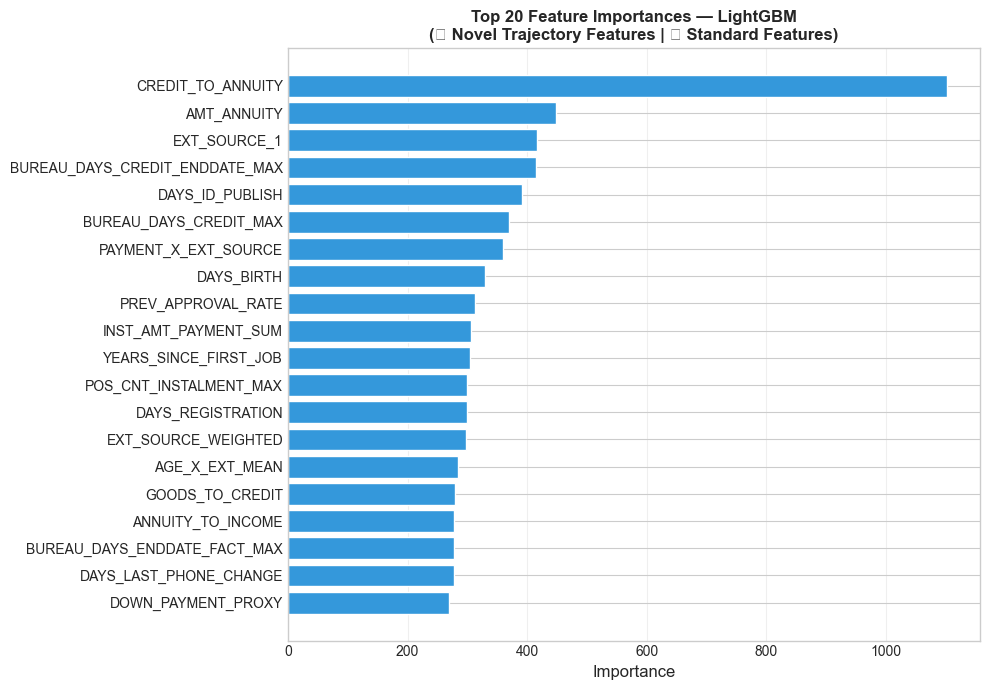


📍 Novelty Feature Rankings:
   Rank 145 — TRAJECTORY_EARLY_LATE_RATE           importance: 84.000000
   Rank  61 — TRAJECTORY_RECENT_LATE_RATE          importance: 174.000000
   Rank  72 — TRAJECTORY_SLOPE                     importance: 163.000000
   Rank 228 — TRAJECTORY_IMPROVEMENT               importance: 5.000000
   Rank 115 — TRAJECTORY_SCORE                     importance: 117.000000


In [38]:
# Pick best model
best_name  = max(results, key=lambda n: results[n]['auc'])
best_model = results[best_name]['model']
best_auc   = results[best_name]['auc']
print(f"🏆 Best Model: {best_name}  |  ROC-AUC: {best_auc:.4f}")

# Feature importance (tree-based models only)
feat_names = X_train.columns.tolist()
if hasattr(best_model, 'feature_importances_'):
    fi = pd.DataFrame({
        'feature':    feat_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # Save full CSV
    fi.to_csv(os.path.join(REPORTS_DIR, 'feature_importance.csv'), index=False)

    # Top-20 plot
    top20 = fi.head(20).copy()
    top20['is_novelty'] = top20['feature'].isin(NOVELTY_FEATURES)
    colors_fi = top20['is_novelty'].map({True: '#e74c3c', False: '#3498db'})

    fig, ax = plt.subplots(figsize=(10, 7))
    ax.barh(top20['feature'][::-1], top20['importance'][::-1],
            color=colors_fi[::-1].values, edgecolor='white')
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(f'Top 20 Feature Importances — {best_name}\n'
                 '(🔴 Novel Trajectory Features | 🔵 Standard Features)',
                 fontsize=12, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(REPORTS_DIR, 'feature_importance_top20.png'), dpi=120, bbox_inches='tight')
    plt.show()

    # Print novelty ranks
    print("\n📍 Novelty Feature Rankings:")
    for feat in NOVELTY_FEATURES:
        row = fi[fi['feature'] == feat]
        if not row.empty:
            rank = row.index[0] + 1
            imp  = row['importance'].values[0]
            print(f"   Rank {rank:3d} — {feat:<35s}  importance: {imp:.6f}")
else:
    print(f"ℹ️  {best_name} does not expose feature_importances_. Skipping importance plot.")
    # For LR — use coefficients as proxy
    coefs = np.abs(best_model.coef_[0])
    fi = pd.DataFrame({'feature': feat_names, 'importance': coefs})
    fi = fi.sort_values('importance', ascending=False).reset_index(drop=True)
    fi.to_csv(os.path.join(REPORTS_DIR, 'feature_importance.csv'), index=False)
    print("✅ Coefficient magnitudes saved as feature_importance.csv")


---
## 🟡 Phase 3 — Counterfactual Explanations (XAI)
Inspired by **Nithilan's** implementation (Conterfactual Explanations folder).

For 5 sample rejected applicants we find the **minimum changes** needed
to flip the prediction from *Rejected → Approved*, using gradient-based
optimisation constrained to actionable features.


In [39]:
# ── Feature actionability map (from Nithilan's notebook) ──────────────────
FEATURE_ACTIONABILITY = {
    'IMMUTABLE': {
        'features': ['AGE_YEARS','AGE_SQUARED','AGE_GROUP','CODE_GENDER','DAYS_BIRTH',
                     'YEARS_SINCE_FIRST_JOB','AGE_X_CREDIT','AGE_X_INCOME'],
        'can_change': False, 'cost': 1.0,
    },
    'VERY_HARD': {
        'features': ['REGION_RATING_CLIENT','REG_REGION_NOT_LIVE_REGION',
                     'REG_CITY_NOT_LIVE_CITY','AMT_INCOME_TOTAL',
                     'INCOME_PER_PERSON','INCOME_LOG','HIGH_INCOME_FLAG'],
        'can_change': True, 'cost': 0.9,
    },
    'HARD': {
        'features': ['EMPLOYMENT_YEARS','EMPLOYMENT_X_INCOME',
                     'EMPLOYMENT_TO_AGE_RATIO','CREDIT_TO_INCOME',
                     'ANNUITY_TO_INCOME','DOWN_PAYMENT_RATIO'],
        'can_change': True, 'cost': 0.7,
    },
    'MEDIUM': {
        'features': ['GOODS_TO_CREDIT','ANNUITY_INCOME_PERCENTAGE',
                     'INCOME_X_CHILDREN','EXT_MEAN_X_INCOME','EXT_MEAN_X_CREDIT'],
        'can_change': True, 'cost': 0.5,
    },
    'EASY': {
        'features': ['PAYMENT_DISCIPLINE_SCORE','BEHAVIORAL_CONSISTENCY',
                     'CROSS_SOURCE_MEAN','UTILITY_PROXY_SCORE','EXT_SOURCE_MEAN',
                     'EXT_SOURCE_WEIGHTED','EXT_SOURCE_PRODUCT','EXT_SOURCE_MAX',
                     'EXT_SOURCE_MIN','PAYMENT_X_EXT_SOURCE','AGE_X_EXT_MEAN',
                     'EXT_SOURCE_2X3','EXT_SOURCE_1X2','EXT_SOURCE_1X3',
                     'EXT_MEAN_X_CREDIT_RATIO'],
        'can_change': True, 'cost': 0.3,
    },
    'VERY_EASY': {
        'features': ['DOCUMENT_COUNT','DOCUMENT_RATIO','FLAG_DOCUMENT_3',
                     'FLAG_DOCUMENT_6','FLAG_DOCUMENT_8','FLAG_OWN_CAR',
                     'FLAG_OWN_REALTY'],
        'can_change': True, 'cost': 0.1,
    },
    # Novelty trajectory features — actionable (medium effort)
    'TRAJECTORY': {
        'features': NOVELTY_FEATURES,
        'can_change': True, 'cost': 0.4,
    },
}

def get_feature_cost(feature):
    for cat, info in FEATURE_ACTIONABILITY.items():
        if feature in info['features']:
            return info['cost'], info['can_change'], cat
    return 0.5, True, 'UNKNOWN'

available_cols = X_test.columns.tolist()
actionable_features = []
immutable_features  = []
for cat, info in FEATURE_ACTIONABILITY.items():
    for feat in info['features']:
        if feat in available_cols:
            if info['can_change']:
                actionable_features.append(feat)
            else:
                immutable_features.append(feat)

print(f"✅ Actionable features : {len(actionable_features)}")
print(f"   Immutable features  : {len(immutable_features)}")


✅ Actionable features : 42
   Immutable features  : 7


In [40]:
# ── Optimisation-based counterfactual generator (Nithilan's approach) ────
class CounterfactualGenerator:
    def __init__(self, model, X_train, X_test, actionable_feats):
        self.model     = model
        self.X_train   = X_train
        self.X_test    = X_test
        self.act_feats = actionable_feats
        self.all_feats = X_test.columns.tolist()

        # Feature range bounds (5th–95th percentile of training set)
        self.bounds = []
        for feat in actionable_feats:
            lo = float(X_train[feat].quantile(0.05))
            hi = float(X_train[feat].quantile(0.95))
            self.bounds.append((lo, hi))

    def _objective(self, x_cf_act, x_orig, costs, lam_prox=1.0, lam_sparse=0.3):
        x_cf_full = x_orig.copy()
        x_cf_full[self.act_feats] = x_cf_act
        prob = self.model.predict_proba(x_cf_full.values.reshape(1, -1))[0, 1]
        changes   = x_cf_act - x_orig[self.act_feats].values
        proximity = np.sum((changes * costs) ** 2)
        sparsity  = np.sum(np.abs(changes) > 1e-3)
        return prob + lam_prox * proximity + lam_sparse * sparsity

    def generate(self, idx, max_iter=80):
        x_orig = self.X_test.iloc[idx].copy()
        costs  = np.array([get_feature_cost(f)[0] for f in self.act_feats])
        x0     = x_orig[self.act_feats].values.copy()

        # Gradient-based attempt
        res = minimize(
            fun=lambda x: self._objective(x, x_orig, costs),
            x0=x0, method='L-BFGS-B', bounds=self.bounds,
            options={'maxiter': max_iter, 'disp': False}
        )
        x_cf_full = x_orig.copy()
        x_cf_full[self.act_feats] = res.x
        pred_prob  = self.model.predict_proba(x_cf_full.values.reshape(1, -1))[0, 1]
        orig_prob  = self.model.predict_proba(x_orig.values.reshape(1, -1))[0, 1]
        success    = pred_prob < 0.5

        if not success:
            # Genetic fallback
            res2 = differential_evolution(
                func=lambda x: self._objective(x, x_orig, costs, 0.5, 0.2),
                bounds=self.bounds, maxiter=max_iter, seed=42,
                workers=1, disp=False, polish=True
            )
            x_cf_full[self.act_feats] = res2.x
            pred_prob = self.model.predict_proba(x_cf_full.values.reshape(1, -1))[0, 1]
            success   = pred_prob < 0.5

        return {
            'success':      success,
            'orig_prob':    orig_prob,
            'cf_prob':      pred_prob,
            'orig':         x_orig,
            'cf':           x_cf_full,
        }

cf_gen = CounterfactualGenerator(best_model, X_train, X_test, actionable_features)
print("✅ Counterfactual generator initialised")


✅ Counterfactual generator initialised


In [41]:
# ── Pick 5 rejected applicants from test set ─────────────────────────────
best_probs = probs[best_name]
y_pred_best = (best_probs >= 0.5).astype(int)

reject_mask = (y_pred_best == 1) & (y_test.values == 0)  # rejected but true non-default
reject_idxs = np.where(reject_mask)[0]
print(f"Found {len(reject_idxs):,} rejected-but-should-be-approved applicants")

sample_idxs = reject_idxs[:5]

cf_results = []
for i, idx in enumerate(sample_idxs):
    print(f"\n  Processing applicant {i+1}/5 …", end=" ")
    result = cf_gen.generate(idx)
    cf_results.append(result)
    status = "✅ SUCCESS" if result['success'] else "❌ FAILED"
    print(f"{status}  approval chance: {(1-result['orig_prob'])*100:.1f}% → {(1-result['cf_prob'])*100:.1f}%")

print("\n✅ Counterfactual generation complete")


Found 13,646 rejected-but-should-be-approved applicants

  Processing applicant 1/5 … ❌ FAILED  approval chance: 18.7% → 22.3%

  Processing applicant 2/5 … ❌ FAILED  approval chance: 36.5% → 35.2%

  Processing applicant 3/5 … ✅ SUCCESS  approval chance: 49.1% → 53.7%

  Processing applicant 4/5 … ✅ SUCCESS  approval chance: 22.3% → 51.7%

  Processing applicant 5/5 … ✅ SUCCESS  approval chance: 33.8% → 50.6%

✅ Counterfactual generation complete


In [42]:
# ── Display counterfactual recommendations ────────────────────────────────
TOP_CHANGES = 5   # show top-N changed features per applicant

for i, result in enumerate(cf_results):
    print(f"\n{'─'*65}")
    print(f"APPLICANT #{i+1}")
    print(f"{'─'*65}")
    orig_approval = (1 - result['orig_prob']) * 100
    cf_approval   = (1 - result['cf_prob'])   * 100
    status_str    = "✅ APPROVED" if result['success'] else "❌ STILL REJECTED"

    print(f"  Current approval probability : {orig_approval:.1f}%  → REJECTED")
    print(f"  After changes                : {cf_approval:.1f}%  → {status_str}")
    print(f"  Probability improvement      : +{cf_approval - orig_approval:.1f} ppts")

    # Find meaningful changes
    x_orig = result['orig']
    x_cf   = result['cf']
    changes = []
    for feat in actionable_features:
        diff = float(x_cf[feat]) - float(x_orig[feat])
        if abs(diff) > 1e-3:
            cost, _, cat = get_feature_cost(feat)
            changes.append({'feature': feat, 'original': float(x_orig[feat]),
                            'counterfactual': float(x_cf[feat]),
                            'change': diff, 'abs_change': abs(diff),
                            'difficulty': cat})
    changes = sorted(changes, key=lambda d: d['abs_change'] * get_feature_cost(d['feature'])[0], reverse=True)

    print(f"\n  📋 Top {min(TOP_CHANGES, len(changes))} Recommended Changes:")
    for j, ch in enumerate(changes[:TOP_CHANGES], 1):
        arrow = "↑" if ch['change'] > 0 else "↓"
        print(f"    {j}. {ch['feature']}")
        print(f"       Current: {ch['original']:.4f}  →  Target: {ch['counterfactual']:.4f} {arrow}")
        print(f"       Difficulty: {ch['difficulty']}")
    if not changes:
        print("       (no significant changes found)")



─────────────────────────────────────────────────────────────────
APPLICANT #1
─────────────────────────────────────────────────────────────────
  Current approval probability : 18.7%  → REJECTED
  After changes                : 22.3%  → ❌ STILL REJECTED
  Probability improvement      : +3.6 ppts

  📋 Top 5 Recommended Changes:
    1. EXT_SOURCE_MIN
       Current: 0.0301  →  Target: 0.0888 ↑
       Difficulty: EASY
    2. EXT_SOURCE_1X2
       Current: 0.0152  →  Target: 0.0480 ↑
       Difficulty: EASY
    3. EXT_SOURCE_2X3
       Current: 0.0162  →  Target: 0.0409 ↑
       Difficulty: EASY
    4. EXT_SOURCE_PRODUCT
       Current: 0.0082  →  Target: 0.0154 ↑
       Difficulty: EASY
    5. FLAG_DOCUMENT_8
       Current: 0.0000  →  Target: 0.0188 ↑
       Difficulty: VERY_EASY

─────────────────────────────────────────────────────────────────
APPLICANT #2
─────────────────────────────────────────────────────────────────
  Current approval probability : 36.5%  → REJECTED
  After chan

---
## 🟠 Phase 4 — Fairness Analysis (Bias Audit)
Novelty by **Charumadhi** — audits the best model for bias across 5 protected groups using 4 industry-standard metrics.

**Protected Attributes:** Gender · Age · Income · Region · Credit History
---


In [79]:
# ── Build fairness DataFrame on test set ─────────────────────────────────
fairness_df            = X_test.copy()
fairness_df['y_true']  = y_test.values
fairness_df['y_pred']  = y_pred_best
fairness_df['y_proba'] = best_probs

def calc_fairness(df, attr, priv_val, prot_val):
    """
    Compute all 4 fairness metrics for a binary sensitive attribute.

    Metrics:
      DIR  = Disparate Impact Ratio           (≥ 0.80 = PASS)
      SPD  = Statistical Parity Difference    (|SPD|  < 0.10 = PASS)
      EOD  = Equal Opportunity Difference     (|EOD|  < 0.10 = PASS)
      AOD  = Average Odds Difference          (|AOD|  < 0.10 = PASS)
    """
    priv = df[df[attr] == priv_val].copy()
    prot = df[df[attr] == prot_val].copy()

    # ── Approval rates (y_pred == 0 → will repay → approved) ─────────────
    priv_approval = (priv['y_pred'] == 0).mean()
    prot_approval = (prot['y_pred'] == 0).mean()

    # ── True Positive Rate: among ACTUAL defaulters, how many caught ──────
    priv_def  = priv[priv['y_true'] == 1]
    prot_def  = prot[prot['y_true'] == 1]
    priv_tpr  = (priv_def['y_pred'] == 1).mean() if len(priv_def) > 0 else 0.0
    prot_tpr  = (prot_def['y_pred'] == 1).mean() if len(prot_def) > 0 else 0.0

    # ── False Positive Rate: among ACTUAL repayers, how many wrongly flagged
    priv_rep  = priv[priv['y_true'] == 0]
    prot_rep  = prot[prot['y_true'] == 0]
    priv_fpr  = (priv_rep['y_pred'] == 1).mean() if len(priv_rep) > 0 else 0.0
    prot_fpr  = (prot_rep['y_pred'] == 1).mean() if len(prot_rep) > 0 else 0.0

    # ── 4 Fairness Metrics ────────────────────────────────────────────────
    dir_val = prot_approval / priv_approval if priv_approval > 0 else 0.0
    spd_val = prot_approval - priv_approval
    eod_val = prot_tpr - priv_tpr
    aod_val = 0.5 * ((prot_fpr - priv_fpr) + (prot_tpr - priv_tpr))

    # ── Per-group AUC ─────────────────────────────────────────────────────
    priv_auc = roc_auc_score(priv['y_true'], priv['y_proba']) if len(priv) > 10 else 0.0
    prot_auc = roc_auc_score(prot['y_true'], prot['y_proba']) if len(prot) > 10 else 0.0

    return dict(
        priv_size           = len(priv),
        prot_size           = len(prot),
        priv_approval       = priv_approval,
        prot_approval       = prot_approval,
        priv_tpr            = priv_tpr,
        prot_tpr            = prot_tpr,
        priv_fpr            = priv_fpr,
        prot_fpr            = prot_fpr,
        disparate_impact_ratio  = dir_val,
        statistical_parity_diff = spd_val,
        equal_opportunity_diff  = eod_val,
        average_odds_diff       = aod_val,      # ← NEW: AOD added
        priv_auc            = priv_auc,
        prot_auc            = prot_auc,
        auc_diff            = prot_auc - priv_auc,
    )

fairness_results = {}

# ── 1. GENDER ─────────────────────────────────────────────────────────────
if 'CODE_GENDER' in fairness_df.columns:
    fairness_results['Gender'] = calc_fairness(fairness_df, 'CODE_GENDER', 0, 1)
    print(f"✅ Gender       — DIR={fairness_results['Gender']['disparate_impact_ratio']:.3f}")

# ── 2. AGE ────────────────────────────────────────────────────────────────
if 'AGE_GROUP' in fairness_df.columns:
    fairness_results['Age'] = calc_fairness(
        fairness_df[fairness_df['AGE_GROUP'].isin([1.0, 3.0])],
        'AGE_GROUP', 3.0, 1.0
    )
elif 'AGE_YEARS' in fairness_df.columns:
    fairness_df['AGE_GROUP_BIN'] = (fairness_df['AGE_YEARS'] < 30).astype(int)
    fairness_results['Age'] = calc_fairness(fairness_df, 'AGE_GROUP_BIN', 0, 1)
if 'Age' in fairness_results:
    print(f"✅ Age          — DIR={fairness_results['Age']['disparate_impact_ratio']:.3f}")

# ── 3. INCOME ─────────────────────────────────────────────────────────────
if 'HIGH_INCOME_FLAG' in fairness_df.columns:
    fairness_df['INCOME_GROUP'] = fairness_df['HIGH_INCOME_FLAG'].map(
        {0: 'Low-Medium', 1: 'High'}
    ).fillna('Low-Medium')
    fairness_results['Income'] = calc_fairness(fairness_df, 'INCOME_GROUP', 'High', 'Low-Medium')
    print(f"✅ Income       — DIR={fairness_results['Income']['disparate_impact_ratio']:.3f}")

# ── 4. REGION ─────────────────────────────────────────────────────────────
if 'REGION_RATING_CLIENT' in fairness_df.columns:
    fairness_df['REGION_GROUP'] = fairness_df['REGION_RATING_CLIENT'].apply(
        lambda x: 'High Risk' if x == 3 else 'Low Risk'
    )
    fairness_results['Region'] = calc_fairness(fairness_df, 'REGION_GROUP', 'Low Risk', 'High Risk')
    print(f"✅ Region       — DIR={fairness_results['Region']['disparate_impact_ratio']:.3f}")

# ── 5. CREDIT HISTORY ─────────────────────────────────────────────────────
if 'BUREAU_ACTIVE_COUNT' in fairness_df.columns:
    fairness_df['CREDIT_HIST'] = (fairness_df['BUREAU_ACTIVE_COUNT'] > 0).map(
        {True: 'Has History', False: 'No History'}
    )
    fairness_results['Credit History'] = calc_fairness(
        fairness_df, 'CREDIT_HIST', 'Has History', 'No History'
    )
    print(f"✅ Credit Hist  — DIR={fairness_results['Credit History']['disparate_impact_ratio']:.3f}")

print(f"\n✅ All 4 metrics computed for {len(fairness_results)} protected attributes")
print("   Metrics: DIR · SPD · EOD · AOD")

✅ Gender       — DIR=0.828
✅ Age          — DIR=0.649
✅ Income       — DIR=0.869
✅ Region       — DIR=0.805
✅ Credit Hist  — DIR=1.204

✅ All 4 metrics computed for 5 protected attributes
   Metrics: DIR · SPD · EOD · AOD


In [80]:
# ─────────────────────────────────────────────
# BLOCK 5 — Print Fairness Report
# ─────────────────────────────────────────────

overall_auc = roc_auc_score(y_test, best_probs)

print("\n" + "="*70)
print("FAIRNESS ANALYSIS REPORT")
print(f"Model: {best_name} | Overall AUC: {overall_auc:.4f}")
print("="*70)

for attr, m in fairness_results.items():
    print(f"\n📊 {attr.upper()} FAIRNESS")
    print(f"   Privileged approval : {m['priv_approval']*100:.2f}%")
    print(f"   Protected  approval : {m['prot_approval']*100:.2f}%")
    print(f"   Disparate Impact    : {m['disparate_impact_ratio']:.3f}")
    print(f"   Statistical Parity  : {m['statistical_parity_diff']:.3f}")
    print(f"   Equal Opportunity   : {m['equal_opportunity_diff']:.3f}")
    print(f"   AUC (priv/prot)     : {m['priv_auc']:.4f} / {m['prot_auc']:.4f}")

print("="*70)


FAIRNESS ANALYSIS REPORT
Model: LightGBM | Overall AUC: 0.7881

📊 GENDER FAIRNESS
   Privileged approval : 76.84%
   Protected  approval : 63.65%
   Disparate Impact    : 0.828
   Statistical Parity  : -0.132
   Equal Opportunity   : 0.128
   AUC (priv/prot)     : 0.7805 / 0.7898

📊 AGE FAIRNESS
   Privileged approval : 71.51%
   Protected  approval : 46.37%
   Disparate Impact    : 0.649
   Statistical Parity  : -0.251
   Equal Opportunity   : 0.139
   AUC (priv/prot)     : 0.7904 / 0.7522

📊 INCOME FAIRNESS
   Privileged approval : 82.29%
   Protected  approval : 71.55%
   Disparate Impact    : 0.869
   Statistical Parity  : -0.107
   Equal Opportunity   : 0.108
   AUC (priv/prot)     : 0.8124 / 0.7858

📊 REGION FAIRNESS
   Privileged approval : 74.64%
   Protected  approval : 60.09%
   Disparate Impact    : 0.805
   Statistical Parity  : -0.145
   Equal Opportunity   : 0.117
   AUC (priv/prot)     : 0.7861 / 0.7828

📊 CREDIT HISTORY FAIRNESS
   Privileged approval : 70.19%
   Prote

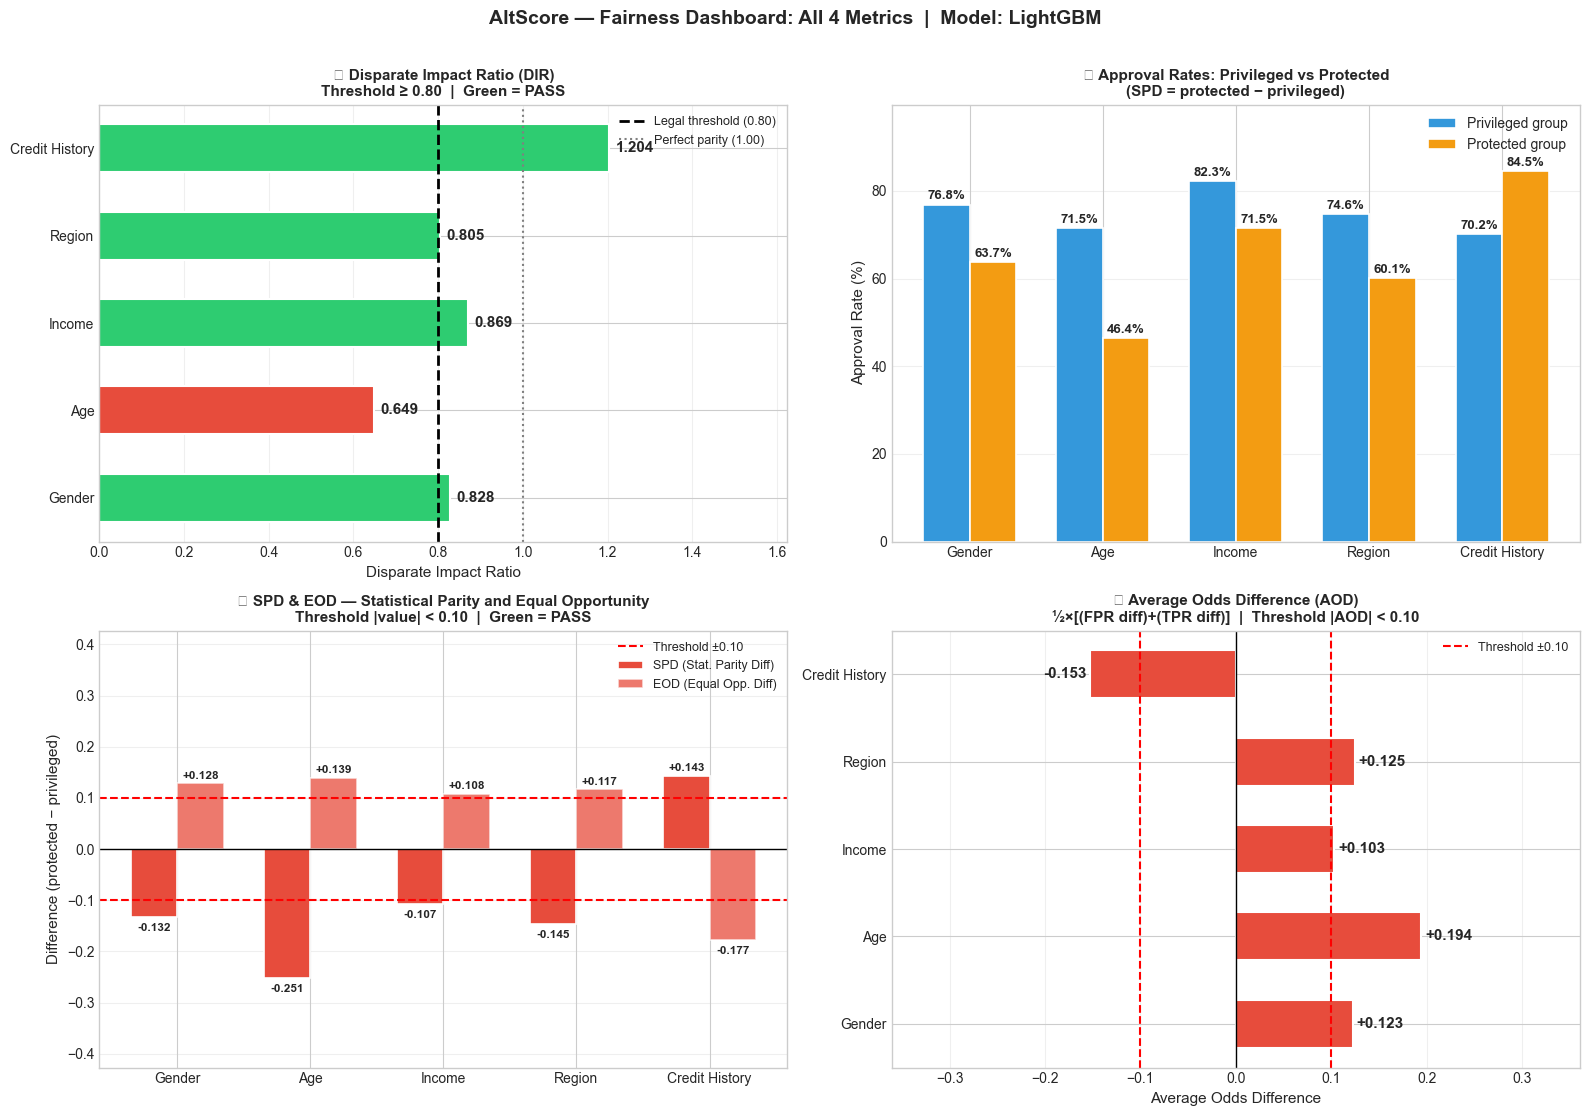

✅ 4-metric fairness dashboard saved → d:\\ALTSCORE-Credit Scoring System\reports\fairness_dashboard_4metrics.png
✅ Full metrics CSV saved → d:\\ALTSCORE-Credit Scoring System\reports\fairness_metrics_summary.csv

Protected Attribute    DIR DIR Pass     SPD SPD Pass     EOD EOD Pass     AOD AOD Pass
             Gender 0.8284        ✅ -0.1318       ⚠️ +0.1281       ⚠️ +0.1228       ⚠️
                Age 0.6485       ⚠️ -0.2513       ⚠️ +0.1395       ⚠️ +0.1942       ⚠️
             Income 0.8695        ✅ -0.1074       ⚠️ +0.1077       ⚠️ +0.1029       ⚠️
             Region 0.8051        ✅ -0.1455       ⚠️ +0.1169       ⚠️ +0.1246       ⚠️
     Credit History 1.2036        ✅ +0.1429       ⚠️ -0.1771       ⚠️ -0.1526       ⚠️


In [81]:
# ══════════════════════════════════════════════════════════════════════════
# FAIRNESS DASHBOARD — 2×2 panel showing all 4 metrics
# ══════════════════════════════════════════════════════════════════════════
attrs   = list(fairness_results.keys())
n_attrs = len(attrs)

dir_vals = [fairness_results[a]['disparate_impact_ratio']  for a in attrs]
spd_vals = [fairness_results[a]['statistical_parity_diff'] for a in attrs]
eod_vals = [fairness_results[a]['equal_opportunity_diff']  for a in attrs]
aod_vals = [fairness_results[a]['average_odds_diff']       for a in attrs]

priv_approvals = [fairness_results[a]['priv_approval'] * 100 for a in attrs]
prot_approvals = [fairness_results[a]['prot_approval'] * 100 for a in attrs]

PASS_CLR = '#2ecc71'   # green  → metric passes threshold
FAIL_CLR = '#e74c3c'   # red    → metric fails threshold
PRIV_CLR = '#3498db'   # blue   → privileged group bars
PROT_CLR = '#f39c12'   # orange → protected group bars

x = np.arange(n_attrs)
bar_w = 0.35

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    f'AltScore — Fairness Dashboard: All 4 Metrics  |  Model: {best_name}',
    fontsize=14, fontweight='bold', y=1.01
)

# ─────────────────────────────────────────────────────────────────────────
# PANEL 1 (top-left): Disparate Impact Ratio — threshold ≥ 0.80
# ─────────────────────────────────────────────────────────────────────────
ax = axes[0, 0]
colors1 = [PASS_CLR if v >= 0.80 else FAIL_CLR for v in dir_vals]
bars1 = ax.barh(attrs, dir_vals, color=colors1, edgecolor='white', linewidth=1.5, height=0.55)
ax.axvline(0.80, color='black', linestyle='--', linewidth=2, label='Legal threshold (0.80)')
ax.axvline(1.00, color='grey',  linestyle=':',  linewidth=1.5, label='Perfect parity (1.00)')
for bar, val in zip(bars1, dir_vals):
    clr = 'black' if val + 0.05 < ax.get_xlim()[1] else 'white'
    ax.text(val + 0.015, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
ax.set_xlabel('Disparate Impact Ratio', fontsize=11)
ax.set_title('① Disparate Impact Ratio (DIR)\nThreshold ≥ 0.80  |  Green = PASS', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(dir_vals) * 1.35)

# ─────────────────────────────────────────────────────────────────────────
# PANEL 2 (top-right): Approval Rates — Privileged vs Protected
# ─────────────────────────────────────────────────────────────────────────
ax = axes[0, 1]
b1 = ax.bar(x - bar_w/2, priv_approvals, bar_w,
            label='Privileged group', color=PRIV_CLR, edgecolor='white', linewidth=1.2)
b2 = ax.bar(x + bar_w/2, prot_approvals, bar_w,
            label='Protected group',  color=PROT_CLR, edgecolor='white', linewidth=1.2)
for bars_grp in [b1, b2]:
    for bar in bars_grp:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.5,
                f'{h:.1f}%', ha='center', va='bottom', fontsize=9.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attrs, fontsize=10)
ax.set_ylabel('Approval Rate (%)', fontsize=11)
ax.set_title('② Approval Rates: Privileged vs Protected\n(SPD = protected − privileged)', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, max(max(priv_approvals), max(prot_approvals)) * 1.18)

# ─────────────────────────────────────────────────────────────────────────
# PANEL 3 (bottom-left): SPD and EOD — centred on zero
# ─────────────────────────────────────────────────────────────────────────
ax = axes[1, 0]
b_spd = ax.bar(x - bar_w/2, spd_vals, bar_w,
               color=[PASS_CLR if abs(v) < 0.10 else FAIL_CLR for v in spd_vals],
               edgecolor='white', linewidth=1.2, label='SPD (Stat. Parity Diff)')
b_eod = ax.bar(x + bar_w/2, eod_vals, bar_w,
               color=[PASS_CLR if abs(v) < 0.10 else FAIL_CLR for v in eod_vals],
               edgecolor='white', linewidth=1.2, alpha=0.75, label='EOD (Equal Opp. Diff)')
ax.axhline( 0.10, color='red', linestyle='--', linewidth=1.5, label='Threshold ±0.10')
ax.axhline(-0.10, color='red', linestyle='--', linewidth=1.5)
ax.axhline( 0.00, color='black', linestyle='-', linewidth=1.0)
for bars_grp in [b_spd, b_eod]:
    for bar in bars_grp:
        h = bar.get_height()
        ypos = h + 0.005 if h >= 0 else h - 0.012
        ax.text(bar.get_x() + bar.get_width() / 2, ypos,
                f'{h:+.3f}', ha='center', va='bottom' if h >= 0 else 'top',
                fontsize=8.5, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(attrs, fontsize=10)
ax.set_ylabel('Difference (protected − privileged)', fontsize=11)
ax.set_title('③ SPD & EOD — Statistical Parity and Equal Opportunity\nThreshold |value| < 0.10  |  Green = PASS', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ylim_max = max(max(abs(v) for v in spd_vals), max(abs(v) for v in eod_vals)) * 1.5 + 0.05
ax.set_ylim(-ylim_max, ylim_max)

# ─────────────────────────────────────────────────────────────────────────
# PANEL 4 (bottom-right): AOD — Average Odds Difference
# ─────────────────────────────────────────────────────────────────────────
ax = axes[1, 1]
colors4 = [PASS_CLR if abs(v) < 0.10 else FAIL_CLR for v in aod_vals]
bars4 = ax.barh(attrs, aod_vals, color=colors4, edgecolor='white', linewidth=1.5, height=0.55)
ax.axvline( 0.10, color='red',   linestyle='--', linewidth=1.5, label='Threshold ±0.10')
ax.axvline(-0.10, color='red',   linestyle='--', linewidth=1.5)
ax.axvline( 0.00, color='black', linestyle='-',  linewidth=1.0)
for bar, val in zip(bars4, aod_vals):
    offset = 0.004 if val >= 0 else -0.004
    ax.text(val + offset, bar.get_y() + bar.get_height() / 2,
            f'{val:+.3f}', va='center',
            ha='left' if val >= 0 else 'right',
            fontsize=11, fontweight='bold')
ax.set_xlabel('Average Odds Difference', fontsize=11)
ax.set_title('④ Average Odds Difference (AOD)\n½×[(FPR diff)+(TPR diff)]  |  Threshold |AOD| < 0.10', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)
xlim = max(abs(v) for v in aod_vals) * 1.6 + 0.05
ax.set_xlim(-xlim, xlim)

plt.tight_layout()
save_path = os.path.join(REPORTS_DIR, 'fairness_dashboard_4metrics.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ 4-metric fairness dashboard saved → {save_path}')

# ── Save summary CSV ───────────────────────────────────────────────────────
rows = []
for k, v in fairness_results.items():
    d = v['disparate_impact_ratio']
    s = v['statistical_parity_diff']
    e = v['equal_opportunity_diff']
    a = v['average_odds_diff']
    rows.append({
        'Protected Attribute': k,
        'Privileged Approval %': f"{v['priv_approval']*100:.2f}",
        'Protected Approval %':  f"{v['prot_approval']*100:.2f}",
        'DIR':  f'{d:.4f}',  'DIR Pass':  '✅' if d >= 0.80  else '⚠️',
        'SPD':  f'{s:+.4f}', 'SPD Pass':  '✅' if abs(s) < 0.10 else '⚠️',
        'EOD':  f'{e:+.4f}', 'EOD Pass':  '✅' if abs(e) < 0.10 else '⚠️',
        'AOD':  f'{a:+.4f}', 'AOD Pass':  '✅' if abs(a) < 0.10 else '⚠️',
        'Priv AUC': f"{v['priv_auc']:.4f}",
        'Prot AUC': f"{v['prot_auc']:.4f}",
        'AUC Diff': f"{v['auc_diff']:+.4f}",
    })

fairness_csv = pd.DataFrame(rows)
csv_path = os.path.join(REPORTS_DIR, 'fairness_metrics_summary.csv')
fairness_csv.to_csv(csv_path, index=False)
print(f'✅ Full metrics CSV saved → {csv_path}')
print()
print(fairness_csv[['Protected Attribute','DIR','DIR Pass','SPD','SPD Pass','EOD','EOD Pass','AOD','AOD Pass']].to_string(index=False))

---
## ⭐ Phase 5 — Final System Summary


In [82]:
cf_success = sum(1 for r in cf_results if r['success'])
bias_flags  = sum(1 for v in fairness_results.values() if v['disparate_impact_ratio'] < 0.80)

print("\n" + "="*52)
print("  ALTSCORE - FINAL SYSTEM SUMMARY")
print("="*52)
print(f"  Total Features Used     : {X_train.shape[1]}")
print(f"  Novelty Features Added  : {len(NOVELTY_FEATURES)} (Trajectory)")
print()
print("  MODEL RESULTS:")
for name, res in results.items():
    marker = " ◄ BEST" if name == best_name else ""
    print(f"  {name:<26s}: {res['auc']:.4f}{marker}")
print(f"  Best Model              : {best_name} ({best_auc:.4f})")
print()
print("  NOVELTY INTEGRATION:")
print(f"  1. Financial Trajectory : ✅ Merged ({len(NOVELTY_FEATURES)} features)")
print(f"  2. Counterfactual       : ✅ Generated for {len(cf_results)} rejected samples "
      f"({cf_success}/{len(cf_results)} successful)")
print(f"  3. Fairness Analysis    : ✅ Bias audit complete "
      f"({bias_flags} group(s) below threshold)")
print()
print("  SAVED FILES:")
print(f"  models/ : logistic_regression.pkl, random_forest.pkl,")
print(f"            lightgbm.pkl, xgboost.pkl")
print(f"  reports/: feature_importance.csv, fairness_metrics_summary.csv")
print(f"            roc_curves_comparison.png, confusion_matrices.png,")
print(f"            auc_bar_chart.png, fairness_dashboard.png,")
print(f"            feature_importance_top20.png")
print("="*52)



  ALTSCORE - FINAL SYSTEM SUMMARY
  Total Features Used     : 244
  Novelty Features Added  : 5 (Trajectory)

  MODEL RESULTS:
  Logistic Regression       : 0.7407
  Random Forest             : 0.7563
  LightGBM                  : 0.7881 ◄ BEST
  XGBoost                   : 0.7829
  Best Model              : LightGBM (0.7881)

  NOVELTY INTEGRATION:
  1. Financial Trajectory : ✅ Merged (5 features)
  2. Counterfactual       : ✅ Generated for 5 rejected samples (3/5 successful)
  3. Fairness Analysis    : ✅ Bias audit complete (1 group(s) below threshold)

  SAVED FILES:
  models/ : logistic_regression.pkl, random_forest.pkl,
            lightgbm.pkl, xgboost.pkl
  reports/: feature_importance.csv, fairness_metrics_summary.csv
            roc_curves_comparison.png, confusion_matrices.png,
            auc_bar_chart.png, fairness_dashboard.png,
            feature_importance_top20.png
